<a href="https://colab.research.google.com/github/seanm27lol/al-/blob/main/_2_Alex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install qiskit_aer
import numpy as np

r=0.05#this is a
alpha=1#well depth
overlap=(2*alpha*r+1)*np.exp(-2*alpha*r)
tii=alpha**2/2
tij=np.exp(-2*alpha*r)*(alpha**2/2-alpha**3*r)
piii=-alpha**2
piji=-alpha**2*np.exp(-4*alpha*r)
piij=-alpha**2*np.exp(-2*alpha*r)
h11=1/(overlap+1)*(tii+tij+piii+piji+2*piij)
h33=1/(1-overlap)*(tii-tij+piii+piji-2*piij)
alpha2=alpha
pppp=alpha2**2/2
pppn=alpha2**2*(np.exp(-2*alpha2*r)/4-np.exp(-6*alpha2*r)/2+np.exp(-2*alpha2*r)/2+np.exp(-6*alpha2*r)/4)
ppnn=2*alpha2**3*np.exp(-4*alpha2*r)*(r+1/4/alpha2)
h1221=(2*pppp+6*ppnn+8*pppn)/4/(1+overlap)**2#2112
h3443=(2*pppp+6*ppnn-8*pppn)/4/(1-overlap)**2
h1331=(2*pppp-2*ppnn)/4/(1+overlap)/(1-overlap)#secondary diagonal
eb=2*h11+h1221
ea=2*h33+h3443
ec=h1331
#print(1/(overlap+1)*(tii+tij))
print(h11)
print(h33)

-1.3638048880574867
17.903420934516195


In [5]:
print(ec)
print(eb)
print(ea)

0.46924520058074165
-2.231866813556555
36.29383613933462


In [6]:
#!pip install qiskit
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from numpy import pi
from qiskit.circuit import Parameter

t=Parameter('t')
trotter = 8
propagator_gates = QuantumCircuit(1)

propagator_gates.p(-eb*t,0)
propagator_gates.x(0)
propagator_gates.p(-eb*t,0)
propagator_gates.x(0)
for i in range(trotter):
  propagator_gates.p((eb-ea)*t/trotter,0)
  propagator_gates.rx(2*ec*t/trotter,0)
propagator = propagator_gates.to_gate()
controlled_u = propagator.control(1)
qreg_q = QuantumRegister(4, 'v')
qreg_eigen = QuantumRegister(1, 'q')
creg_c = ClassicalRegister(4, 'c')
circuit = QuantumCircuit(qreg_eigen, qreg_q, creg_c)

circuit.h(qreg_q[0])
circuit.h(qreg_q[1])
circuit.h(qreg_q[2])
circuit.h(qreg_q[3])

#circuit.ry(correlation,qreg_eigen[0])

for pea in range(4):
  for j in range(2**pea):
    circuit.append(controlled_u, [qreg_q[pea],qreg_eigen[0]])

circuit.swap(qreg_q[0], qreg_q[3])
circuit.swap(qreg_q[1], qreg_q[2])
circuit.h(qreg_q[0])
circuit.cp(-pi / 2, qreg_q[0], qreg_q[1])
circuit.h(qreg_q[1])
circuit.cp(-pi / 4, qreg_q[0], qreg_q[2])
circuit.cp(-pi / 2, qreg_q[1], qreg_q[2])
circuit.h(qreg_q[2])
circuit.cp(-pi / 8, qreg_q[0], qreg_q[3])
circuit.cp(-pi / 4, qreg_q[1], qreg_q[3])
circuit.cp(-pi / 2, qreg_q[2], qreg_q[3])
circuit.h(qreg_q[3])
circuit.measure(qreg_q[0], creg_c[0])
circuit.measure(qreg_q[1], creg_c[1])
circuit.measure(qreg_q[2], creg_c[2])
circuit.measure(qreg_q[3], creg_c[3])

In [7]:
circuit.draw()#('mpl')

┌───────────────┐┌───────────────┐┌───────────────┐┌───────────────┐»
  q: ─────┤ circuit-42(t) ├┤ circuit-42(t) ├┤ circuit-42(t) ├┤ circuit-42(t) ├»
     ┌───┐└───────┬───────┘└───────┬───────┘└───────┬───────┘└───────┬───────┘»
v_0: ┤ H ├────────■────────────────┼────────────────┼────────────────┼────────»
     ├───┤                         │                │                │        »
v_1: ┤ H ├─────────────────────────■────────────────■────────────────┼────────»
     ├───┤                                                           │        »
v_2: ┤ H ├───────────────────────────────────────────────────────────■────────»
     ├───┤                                                                    »
v_3: ┤ H ├────────────────────────────────────────────────────────────────────»
     └───┘                                                                    »
c: 4/═════════════════════════════════════════════════════════════════════════»
                                                                              »
«     ┌───────────────┐┌───────────────┐┌───────────────┐┌───────────────┐   »
«  q: ┤ circuit-42(t) ├┤ circuit-42(t) ├┤ circuit-42(t) ├┤ circuit-42(t) ├───»
«     └───────┬───────┘└───────┬───────┘└───────┬───────┘└───────┬───────┘   »
«v_0: ────────┼────────────────┼────────────────┼────────────────┼───────────»
«             │                │                │                │           »
«v_1: ────────┼────────────────┼────────────────┼────────────────┼─────────X─»
«             │                │                │                │         │ »
«v_2: ────────■────────────────■────────────────■────────────────┼─────────X─»
«                                                                │           »
«v_3: ───────────────────────────────────────────────────────────■───────────»
«                                                                            »
«c: 4/═══════════════════════════════════════════════════════════════════════»
«                                                                            »
«     ┌───────────────┐┌───────────────┐┌───────────────┐┌───────────────┐»
«  q: ┤ circuit-42(t) ├┤ circuit-42(t) ├┤ circuit-42(t) ├┤ circuit-42(t) ├»
«     └───────┬───────┘└───────┬───────┘└───────┬───────┘└───────┬───────┘»
«v_0: ────────┼────────────────┼────────────────┼────────────────┼────────»
«             │                │                │                │        »
«v_1: ────────┼────────────────┼────────────────┼────────────────┼────────»
«             │                │                │                │        »
«v_2: ────────┼────────────────┼────────────────┼────────────────┼────────»
«             │                │                │                │        »
«v_3: ────────■────────────────■────────────────■────────────────■────────»
«                                                                         »
«c: 4/════════════════════════════════════════════════════════════════════»
«                                                                         »
«     ┌───────────────┐┌───────────────┐┌───────────────┐                  »
«  q: ┤ circuit-42(t) ├┤ circuit-42(t) ├┤ circuit-42(t) ├──────────────────»
«     └───────┬───────┘└───────┬───────┘└───────┬───────┘   ┌───┐          »
«v_0: ────────┼────────────────┼────────────────┼─────────X─┤ H ├─■────────»
«             │                │                │         │ └───┘ │P(-π/2) »
«v_1: ────────┼────────────────┼────────────────┼─────────┼───────■────────»
«             │                │                │         │                »
«v_2: ────────┼────────────────┼────────────────┼─────────┼────────────────»
«             │                │                │         │                »
«v_3: ────────■────────────────■────────────────■─────────X────────────────»
«                                                                          »
«c: 4/═════════════════════════════════════════════════════════════════════»
«                              

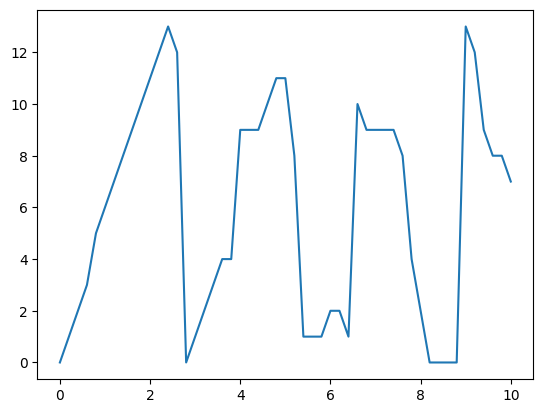

In [8]:
import numpy as np
size=51
stop=10
tValues=np.linspace(0,stop,size)
from qiskit import transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
simulator = AerSimulator()

# Transpile the circuit once outside the loop
# This helps the simulator's compiler handle the circuit structure
transpiled_circuit = transpile(circuit, simulator)

y=np.zeros(size)
for i in range(size):
    # Assign parameters to the transpiled circuit
    qc_bound = transpiled_circuit.assign_parameters({t: tValues[i]})

    # Run and get counts
    job = simulator.run(qc_bound)
    results=job.result()
    counts = results.get_counts(qc_bound)
    y[i]=int(max(counts, key=counts.get),2)
import matplotlib.pyplot as plt
plt.plot(tValues,y,)

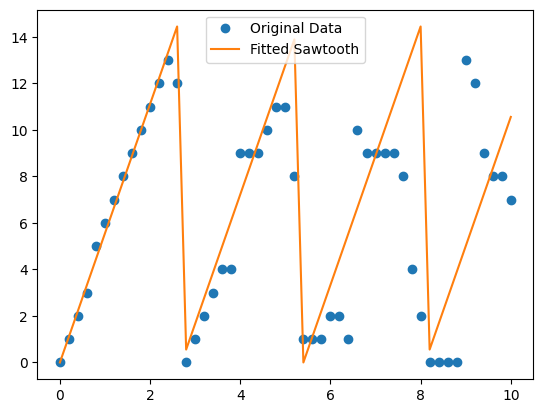

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy.signal

def sawtooth_model(x, frequency):
    return 7.5 * scipy.signal.sawtooth(2 * np.pi * frequency * x) + 7.5

# Fit the curve
popt, pcov = curve_fit(sawtooth_model, tValues, y,.4)
frequency_fit = popt

# Generate fitted data
y_fit = sawtooth_model(tValues, frequency_fit)

# Plot the results
plt.plot(tValues, y, 'o', label='Original Data')
plt.plot(tValues, y_fit, '-', label='Fitted Sawtooth')
plt.legend()
plt.show()

In [14]:
-frequency_fit*2*np.pi

array([-2.32710579])